**Programming Assignment 2 CNN and data competition**

**Import tenserflow**

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (32, 32)

SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TF version:", tf.__version__)

TF version: 2.20.0


**Load and Visualize the sample (cifar 100)**

Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)
Train class distribution: [500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500 500 500 500 500 500 500 500 500]
Test class distribution : [100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100]


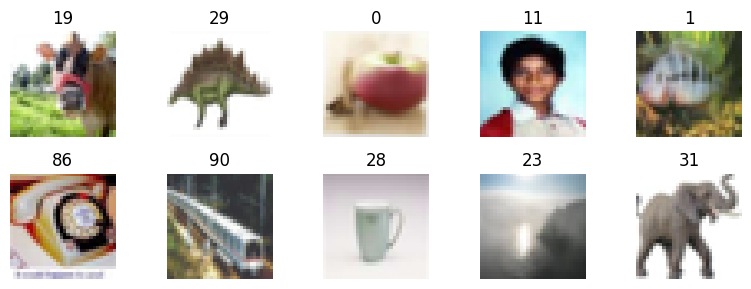

In [17]:
from sklearn.model_selection import train_test_split

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

# Flatten labels (they come as shape (N,1))
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# Count occurrences
train_counts = np.bincount(y_train_flat)
test_counts = np.bincount(y_test_flat)

print("Train class distribution:", train_counts)
print("Test class distribution :", test_counts)

plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])  # no grayscale
    plt.title(int(y_train[i][0]))
    plt.axis("off")
plt.tight_layout()
plt.show()

**Construct a CNN to predict the image labels (cifar 100)**

In [ ]:
from tensorflow.keras import optimizers
from tensorflow.keras import layers, models, regularizers

y_tr = y_tr.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

mean = np.mean(x_tr, axis=(0, 1, 2), keepdims=True) / 255.0
std  = np.std(x_tr, axis=(0, 1, 2), keepdims=True) / 255.0

normalizer = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Normalization(mean=mean, variance=std**2),
], name="norm")

lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6
)

early_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
)


data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_aug")

BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)) \
    .shuffle(50000) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test.flatten())) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_aug,
    normalizer,

    layers.Conv2D(32, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(512, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(512, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
    layers.Dropout(0.4),
    layers.Dense(100, activation="softmax")
])

model.summary()

steps_per_epoch = int(np.ceil(len(x_tr) / BATCH_SIZE))
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-3,
    decay_steps=steps_per_epoch * 150,
    alpha=1e-2
)

opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=[early_cb, lr_cb],
    verbose=1
)

plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy (CIFAR-100)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss (CIFAR-100)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm (Sequential)               │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,875,204 (18.60 MB)

 Trainable params: 4,871,236 (18.58 MB)

 Non-trainable params: 3,968 (15.50 KB)

Epoch 1/400
176/176 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.0159 - loss: 5.6471 - val_accuracy: 0.0128 - val_loss: 5.5778 - learning_rate: 0.0010
Epoch 2/400
  4/176 ━━━━━━━━━━━━━━━━━━━━ 3:40 1s/step - accuracy: 0.0152 - loss: 5.0599

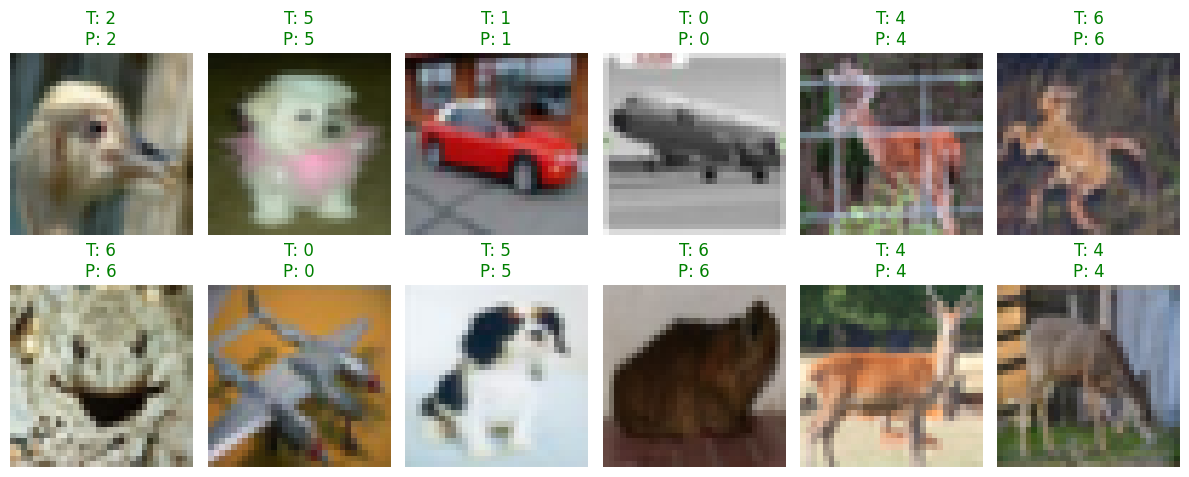

In [10]:
from PredictionViewer import PredictionViewer

viewer = PredictionViewer(model)
viewer.show_predictions(x_test, y_test.flatten(), num_images=12)